<a href="https://colab.research.google.com/github/viniciuscristall-spec/CP02_ML/blob/main/Checkpoint_02_Parte_1_Modelos_de_Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Regressão linear com dados de energia solar (PVGIS)

André Debiazzi: RM569062

Kaique da Silva: RM572718

Vinicius Cristal: RM572049

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
CIDADE     = "Petrolina - PE"
LATITUDE   = -9.39
LONGITUDE  = -40.50
ANO_INICIO = 2020
ANO_FIM    = 2022

URL_BASE = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"

params = {
    "lat": LATITUDE,
    "lon": LONGITUDE,
    "startyear": ANO_INICIO,
    "endyear": ANO_FIM,
    "pvcalculation": 1,
    "peakpower": 1,
    "loss": 14,
    "angle": 10,
    "aspect": 180,
    "outputformat": "json",
}
print("Cidade:", CIDADE)
print("Latitude / Longitude:", LATITUDE, LONGITUDE)
print("Período:", ANO_INICIO, "a", ANO_FIM)

Cidade: Petrolina - PE
Latitude / Longitude: -9.39 -40.5
Período: 2020 a 2022


In [15]:
resposta = requests.get(URL_BASE, params=params, timeout=120)
dados = resposta.json()

In [17]:
df_bruto = pd.DataFrame(dados["outputs"]["hourly"])
df_bruto["time"] = pd.to_datetime(df_bruto["time"], format="%Y%m%d:%H%M")
df = (df_bruto[["time", "P", "G(i)", "H_sun", "T2m", "WS10m"]]
      .rename(columns={"G(i)": "G_i"})
      .set_index("time"))

df.head()

,P,G_i,H_sun,T2m,WS10m
time,,,,,
2020-01-01 00:04:00,0.0,0.0,0.0,26.47,1.86
2020-01-01 01:04:00,0.0,0.0,0.0,26.34,2.21
2020-01-01 02:04:00,0.0,0.0,0.0,26.13,2.69
2020-01-01 03:04:00,0.0,0.0,0.0,25.63,2.48
2020-01-01 04:04:00,0.0,0.0,0.0,24.71,2.00


In [27]:
df.shape

(26304, 5)

In [28]:
df.describe()

,P,G_i,H_sun,T2m,WS10m
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,183.858926,244.915409,20.380481,26.621355,4.232000
std,253.429302,334.400634,26.096683,4.055463,1.583137
min,0.000000,0.000000,0.000000,17.180000,0.000000
25%,0.000000,0.000000,0.000000,23.460000,3.240000
50%,0.000000,0.000000,0.000000,26.130000,4.340000
75%,371.807500,480.862500,41.257500,29.630000,5.310000
max,835.940000,1112.580000,87.740000,37.770000,9.380000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2020-01-01 00:04:00 to 2022-12-31 23:04:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P       26304 non-null  float64
 1   G_i     26304 non-null  float64
 2   H_sun   26304 non-null  float64
 3   T2m     26304 non-null  float64
 4   WS10m   26304 non-null  float64
dtypes: float64(5)
memory usage: 1.2 MB


In [32]:
df.isnull().sum()

,0
P,0
G_i,0
H_sun,0
T2m,0
WS10m,0


Total de horas: 26304
Horas com P = 0      : 13418 (51.0%)
Horas com G_i = 0    : 13324 (50.7%)
Horas com Sol abaixo do horizonte (H_sun <= 0): 13324 (50.7%)


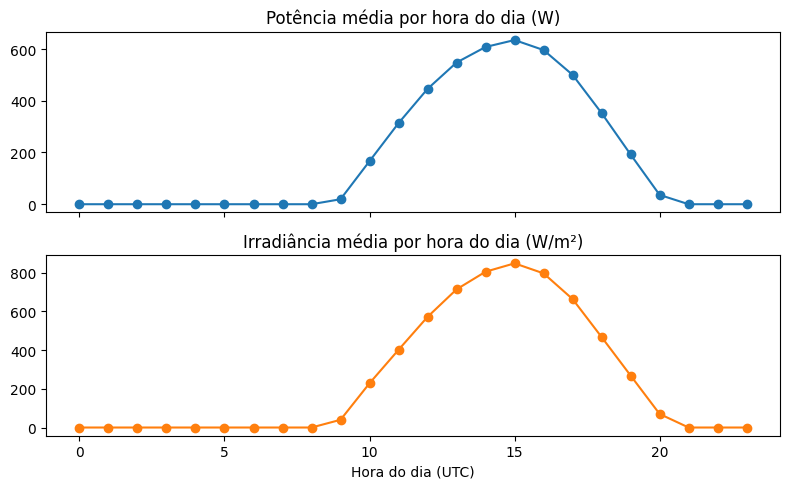

In [34]:
# Registros sem geração ou irradiancia
total = len(df)
sem_geracao   = (df["P"] == 0).sum()
sem_irradiancia = (df["G_i"] == 0).sum()
sol_abaixo_horizonte = (df["H_sun"] <= 0).sum()

print(f"Total de horas: {total}")
print(f"Horas com P = 0      : {sem_geracao} ({sem_geracao/total:.1%})")
print(f"Horas com G_i = 0    : {sem_irradiancia} ({sem_irradiancia/total:.1%})")
print(f"Horas com Sol abaixo do horizonte (H_sun <= 0): {sol_abaixo_horizonte} ({sol_abaixo_horizonte/total:.1%})")

perfil = df.groupby(df.index.hour)[["P", "G_i"]].mean()
ax = perfil.plot(subplots=True, marker="o", figsize=(8, 5), title=["Potência média por hora do dia (W)", "Irradiância média por hora do dia (W/m²)"], legend=False)
plt.xlabel("Hora do dia (UTC)")
plt.tight_layout(); plt.show()

In [36]:
df_dia = df[df["G_i"] > 0].copy()
print("Antes :", df.shape)
print("Depois:", df_dia.shape)
print(f"Registros removidos: {len(df) - len(df_dia)} ({(len(df)-len(df_dia))/len(df):.1%})")
print("\nHoras com P = 0 que permaneceram (G_i > 0):", (df_dia["P"] == 0).sum())
df_dia.describe().round(2)

Antes : (26304, 5)
Depois: (12980, 5)
Registros removidos: 13324 (50.7%)

Horas com P = 0 que permaneceram (G_i > 0): 94


,P,G_i,H_sun,T2m,WS10m
count,12980.00,12980.00,12980.00,12980.00,12980.00
mean,372.59,496.32,41.30,28.34,4.55
std,244.61,319.11,22.72,4.12,1.68
min,0.00,0.99,1.37,17.18,0.07
25%,162.10,222.05,21.66,25.13,3.45
50%,377.96,487.90,42.15,28.55,4.62
75%,594.19,778.90,59.49,31.54,5.79
max,835.94,1112.58,87.74,37.77,9.38


##Definição do problema de regressão

**Problema:** estimar a potência produzida pelo sistema fotovoltaico.

- **y = `P`** (potência FV em W, para um sistema de 1 kWp).
- **Candidatas a X** e justificativa física:

| Variável | Por que pode explicar `P` |
|---|---|
| `G_i` | Irradiância que chega aos módulos: é a **energia de entrada** da conversão; espera-se a relação mais forte |
| `H_sun` | Altura do Sol: determina a espessura de atmosfera atravessada e o ângulo de incidência; correlaciona com `G_i` |
| `T2m` | Temperatura: módulos mais quentes perdem eficiência (efeito negativo, de segunda ordem) |
| `WS10m` | Vento: resfria os módulos, melhorando levemente a eficiência |

A escolha final dos dois conjuntos de variáveis será feita **depois** dos gráficos e da matriz de correlação.

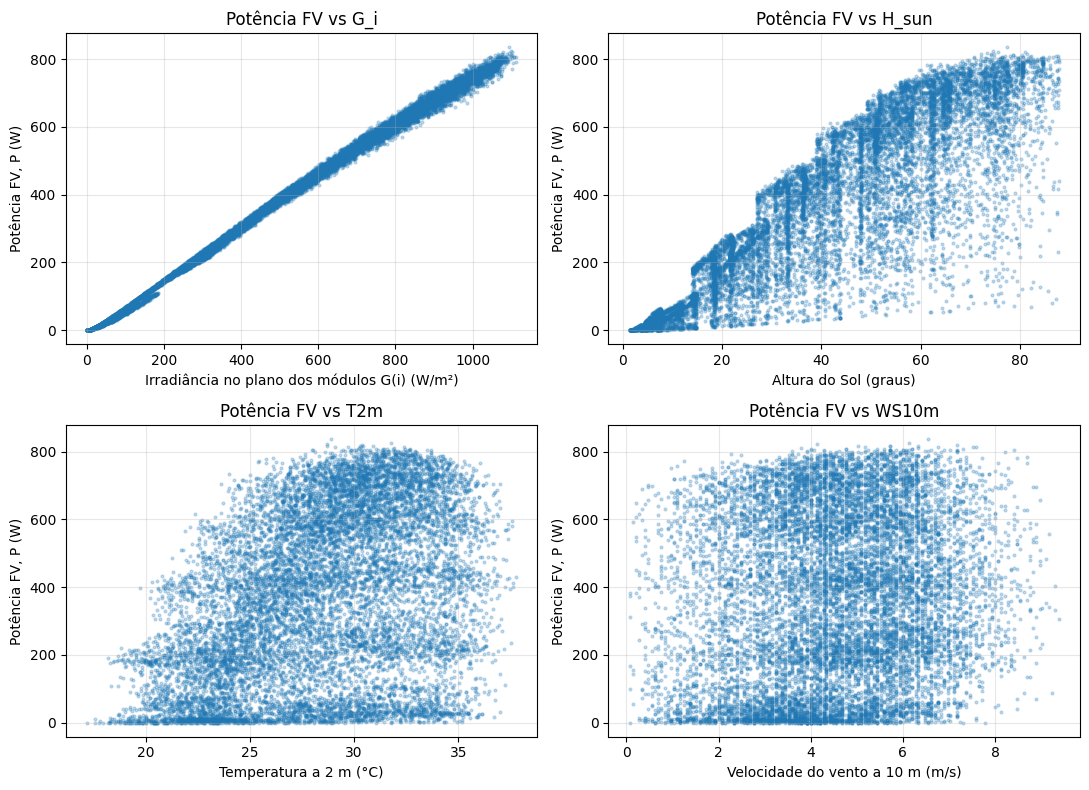

In [37]:
variaveis = ["G_i", "H_sun", "T2m", "WS10m"]
rotulos = {
    "G_i":   "Irradiância no plano dos módulos G(i) (W/m²)",
    "H_sun": "Altura do Sol (graus)",
    "T2m":   "Temperatura a 2 m (°C)",
    "WS10m": "Velocidade do vento a 10 m (m/s)",
}

fig, eixos = plt.subplots(2, 2, figsize=(11, 8))
for ax, var in zip(eixos.ravel(), variaveis):
    ax.scatter(df_dia[var], df_dia["P"], s=4, alpha=0.25)
    ax.set_title(f"Potência FV vs {var}")
    ax.set_xlabel(rotulos[var])
    ax.set_ylabel("Potência FV, P (W)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

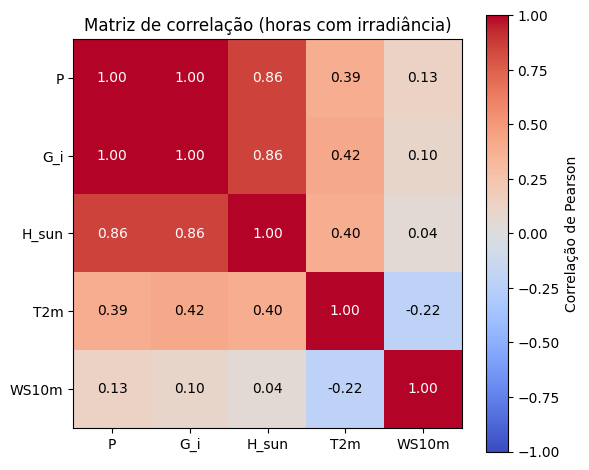

Correlação de cada variável com P (ordenada pelo valor absoluto):
G_i      0.998
H_sun    0.855
T2m      0.392
WS10m    0.127
Name: P, dtype: float64


In [38]:
cols_corr = ["P"] + variaveis
corr = df_dia[cols_corr].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_corr))); ax.set_xticklabels(cols_corr)
ax.set_yticks(range(len(cols_corr))); ax.set_yticklabels(cols_corr)
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
plt.colorbar(im, label="Correlação de Pearson")
ax.set_title("Matriz de correlação (horas com irradiância)")
plt.tight_layout(); plt.show()

corr_P = corr["P"].drop("P").sort_values(key=abs, ascending=False)
print("Correlação de cada variável com P (ordenada pelo valor absoluto):")
print(corr_P.round(3))

In [39]:
mais_corr = corr_P.index[0]
fracas = corr_P[corr_P.abs() < 0.3].index.tolist()
print(f"1) Maior correlação linear com a potência: {mais_corr} (r = {corr_P[mais_corr]:.3f})")
print(f"2) Variáveis com correlação baixa (|r| < 0,3): {fracas if fracas else 'nenhuma'}")
print(f"   Correlação entre G_i e H_sun (possível redundância): {corr.loc['G_i','H_sun']:.3f}")

1) Maior correlação linear com a potência: G_i (r = 0.998)
2) Variáveis com correlação baixa (|r| < 0,3): ['WS10m']
   Correlação entre G_i e H_sun (possível redundância): 0.857


In [40]:
y = df_dia["P"]

vars_modelo1 = ["G_i", "H_sun", "T2m", "WS10m"]
vars_modelo2 = ["G_i", "T2m"]

X1 = df_dia[vars_modelo1]
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

print("Dimensões – Modelo 1")
print("X1_train:", X1_train.shape, "| X1_test:", X1_test.shape)
print("y_train :", y_train.shape,  "| y_test :", y_test.shape)
print(f"Proporção de teste: {len(X1_test)/len(X1):.0%}")

Dimensões – Modelo 1
X1_train: (10384, 4) | X1_test: (2596, 4)
y_train : (10384,) | y_test : (2596,)
Proporção de teste: 20%


In [41]:
modeloLR1 = LinearRegression()
modeloLR1.fit(X1_train, y_train)

y_pred1 = modeloLR1.predict(X1_test)

mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

print("MODELO 1")
print(f"MAE: {mae1:.3f} W")
print(f"MSE: {mse1:.3f} W²")
print(f"R² : {r2_1:.4f}")
print("\nIntercepto:", round(modeloLR1.intercept_, 3))
print("Coeficientes:")
print(pd.Series(modeloLR1.coef_, index=vars_modelo1).round(4))

MODELO 1
MAE: 8.651 W
MSE: 113.019 W²
R² : 0.9981

Intercepto: 15.315
Coeficientes:
G_i      0.7680
H_sun    0.0543
T2m     -1.5265
WS10m    3.7571
dtype: float64


In [42]:
X2 = df_dia[vars_modelo2]
X2_train, X2_test, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

print("Dimensões – Modelo 2")
print("X2_train:", X2_train.shape, "| X2_test:", X2_test.shape)
print("Mesmas linhas de teste que o Modelo 1?", X2_test.index.equals(X1_test.index))

modeloLR2 = LinearRegression()
modeloLR2.fit(X2_train, y_train2)

y_pred2 = modeloLR2.predict(X2_test)

mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("\nMODELO 2")
print(f"MAE: {mae2:.3f} W")
print(f"MSE: {mse2:.3f} W²")
print(f"R² : {r2_2:.4f}")
print("\nIntercepto:", round(modeloLR2.intercept_, 3))
print("Coeficientes:")
print(pd.Series(modeloLR2.coef_, index=vars_modelo2).round(4))

Dimensões – Modelo 2
X2_train: (10384, 2) | X2_test: (2596, 2)
Mesmas linhas de teste que o Modelo 1? True

MODELO 2
MAE: 9.732 W
MSE: 151.578 W²
R² : 0.9974

Intercepto: 44.01
Coeficientes:
G_i    0.7758
T2m   -1.9916
dtype: float64


In [43]:
resultados = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Variáveis utilizadas": [", ".join(vars_modelo1), ", ".join(vars_modelo2)],
    "MAE": [mae1, mae2],
    "MSE": [mse1, mse2],
    "R²":  [r2_1, r2_2],
}).round(4)
resultados

,Modelo,Variáveis utilizadas,MAE,MSE,R²
0,Modelo 1,"G_i, H_sun, T2m, WS10m",8.6513,113.0191,0.9981
1,Modelo 2,"G_i, T2m",9.7319,151.5778,0.9974


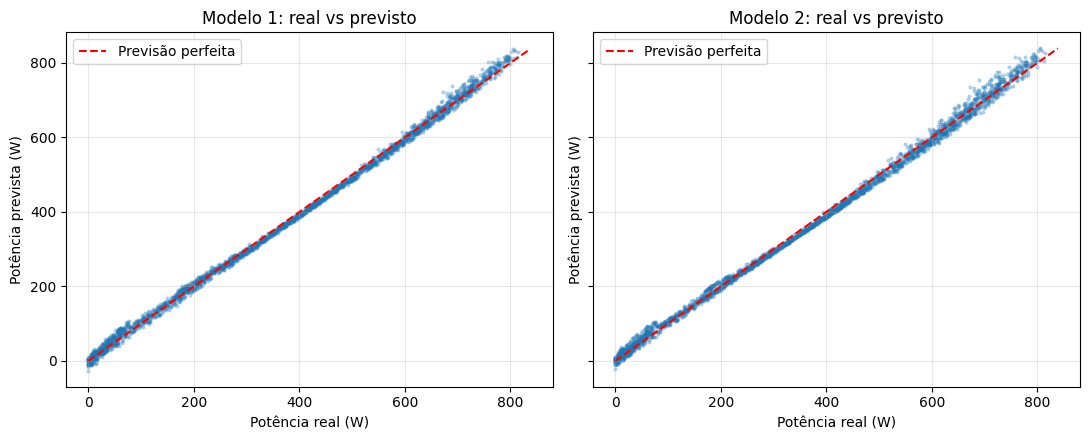

In [44]:
# Valores reais x previstos (conjunto de teste)
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, pred, nome in zip(eixos, [y_pred1, y_pred2], ["Modelo 1", "Modelo 2"]):
    ax.scatter(y_test, pred, s=4, alpha=0.25)
    lim = [0, max(y_test.max(), pred.max())]
    ax.plot(lim, lim, "r--", label="Previsão perfeita")
    ax.set_title(f"{nome}: real vs previsto")
    ax.set_xlabel("Potência real (W)"); ax.set_ylabel("Potência prevista (W)")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [45]:
def melhor(nome_metrica, v1, v2, maior_melhor):
    if np.isclose(v1, v2, rtol=1e-6):
        return "empate"
    if maior_melhor:
        return "Modelo 1" if v1 > v2 else "Modelo 2"
    return "Modelo 1" if v1 < v2 else "Modelo 2"

b_r2  = melhor("R²",  r2_1, r2_2, True)
b_mae = melhor("MAE", mae1, mae2, False)
b_mse = melhor("MSE", mse1, mse2, False)

print(f"1) Maior R²  : {b_r2}  (M1 = {r2_1:.4f} | M2 = {r2_2:.4f})")
print(f"2) Menor MAE : {b_mae}  (M1 = {mae1:.3f} | M2 = {mae2:.3f})")
print(f"3) Menor MSE : {b_mse}  (M1 = {mse1:.3f} | M2 = {mse2:.3f})")
print(f"4) As três métricas apontam para o mesmo modelo? {'SIM' if len({b_r2, b_mae, b_mse}) == 1 else 'NÃO'}")

top2 = corr_P.index[:2].tolist()
print(f"5) As 2 variáveis mais correlacionadas com P foram {top2}. "
      f"Modelo 2 usa {vars_modelo2}; Modelo 1 usa as quatro.")
print(f"   Diferença de R² (M1 − M2): {r2_1 - r2_2:+.5f}  |  diferença de MAE (M1 − M2): {mae1 - mae2:+.3f} W")

1) Maior R²  : Modelo 1  (M1 = 0.9981 | M2 = 0.9974)
2) Menor MAE : Modelo 1  (M1 = 8.651 | M2 = 9.732)
3) Menor MSE : Modelo 1  (M1 = 113.019 | M2 = 151.578)
4) As três métricas apontam para o mesmo modelo? SIM
5) As 2 variáveis mais correlacionadas com P foram ['G_i', 'H_sun']. Modelo 2 usa ['G_i', 'T2m']; Modelo 1 usa as quatro.
   Diferença de R² (M1 − M2): +0.00066  |  diferença de MAE (M1 − M2): -1.081 W


### Análise dos resultados

**1–4. Qual modelo foi melhor?** R², MAE e MSE geralmente concordam, mas têm diferenças. O MSE penaliza mais erros grandes (e caminha sempre junto com o R²), enquanto o MAE trata os erros de forma proporcional.

**5. Maior correlação = melhor modelo?** Maior correlação individual não garante o melhor modelo. O desempenho depende da combinação e complementaridade das variáveis. Modelos mais simples e parcimoniosos devem ser preferidos quando o ganho de variáveis extras é mínimo.

**6. Os gráficos indicam relações aproximadamente lineares?** Linearidade das Relações: G_i possui forte relação linear com a potência. H_sun mostra uma relação moderada e curva, enquanto T2m e WS10m apresentam pouca ou nenhuma linearidade isolada, atuando de forma combinada.

**7. Fatores que dificultam prever a potência por um modelo linear:** A previsão exata é dificultada por não linearidades (como saturação e eficiência variável), interações entre variáveis (temperatura e sol), multicolinearidade, dependência temporal (séries horárias), ausência de dados físicos (sujeira, nebulosidade), dados gerados por simulação (PVGIS) e necessidade de tratamento do período noturno.

### Conclusão

Foram obtidos dados horários reais do PVGIS (já filtrados sem a noite), e dois modelos de Regressão Linear foram treinados na mesma partição e comparados pelas métricas de erro. A irradiância (G_i) explica quase toda a potência, com as outras variáveis trazendo contribuições mínimas. A escolha final equilibra métricas, simplicidade e interpretabilidade.